[<img src="../XRO_logo.png" width="500">](https://github.com/senclimate/XRO) 

Author: Sen Zhao <zhaos@hawaii.edu>

In this notebook, we will how to calculate the XRO state vectors of climate mode indices.
    
See our paper Zhao et al. 2024[[1]](#1) for details of climate mode indices definitions.

If you encounter problems, please feel free to contact Sen Zhao (zhaos@hawaii.edu).

<a id="1">[1]</a> 
Zhao, S., Jin, F.-F., Stuecker, M.F., Thompson, P.R., Kug, J.-S., McPhaden, M.J., Cane, M.A., Wittenberg, A.T., Cai, W.,. Explainable El Niño predictability from climate mode interactions. Nature. https://doi.org/10.1038/s41586-024-07534-6


In [1]:
%config IPCompleter.greedy = True
%matplotlib inline
%config InlineBackend.figure_format='retina'
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import sys
    
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt

sys.path.append("../")  # adjust to repo root

from XRO.state import CDS_ORAS5_Realtime, calc_XRO_indices

from XRO.stats import detrend


## IMPORTANT: CDS API Setup

To use the Copernicus Climate Data Store (CDS) API, follow the official setup guide:

📘 Documentation: https://cds.climate.copernicus.eu/how-to-api
Step 1 — Create your API key

Log in to your CDS account and obtain your API credentials: https://cds.climate.copernicus.eu/profile

Step 2 — Configure your local credentials

Save your token in the file: ~/.cdsapirc


In [2]:
cds = CDS_ORAS5_Realtime()
oras5_data = cds.load_variables(time_slice=slice("1979-01", None))
oras5_data

<xarray.Dataset> Size: 5GB
Dimensions:  (time: 569, lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * time     (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2026-05-01
  * lon      (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Data variables:
    sst      (time, lat, lon) float32 2GB dask.array<chunksize=(12, 64, 62), meta=np.ndarray>
    d20      (time, lat, lon) float32 2GB dask.array<chunksize=(12, 64, 62), meta=np.ndarray>

In [3]:
%%time
XRO_ds = calc_XRO_indices(oras5_data.sst, oras5_data.d20).compute()
XRO_ds

CPU times: user 7.4 s, sys: 1.75 s, total: 9.15 s
Wall time: 15.4 s


<xarray.Dataset> Size: 50kB
Dimensions:  (time: 569)
Coordinates:
  * time     (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2026-05-01
Data variables:
    Nino34   (time) float64 5kB 26.53 26.89 27.26 27.97 ... 27.2 28.24 28.93
    WWV      (time) float64 5kB 140.8 138.6 130.9 125.5 ... 134.0 136.8 134.5
    NPMM     (time) float64 5kB 23.9 23.27 23.32 23.67 ... 24.58 25.36 25.72
    SPMM     (time) float64 5kB 24.21 24.64 24.54 24.47 ... 25.07 24.72 23.99
    IOB      (time) float64 5kB 27.98 28.12 28.64 29.09 ... 28.94 29.54 29.32
    IOD      (time) float64 5kB -0.449 -0.6946 -0.2958 ... 0.3705 -0.2472
    SIOD     (time) float64 5kB -1.051 -0.8628 -0.7254 ... -0.4367 -0.1103
    TNA      (time) float64 5kB 24.95 24.78 24.43 24.9 ... 24.33 24.66 25.29
    ATL3     (time) float64 5kB 27.1 27.67 28.27 28.61 ... 28.98 29.36 28.43
    SASD     (time) float64 5kB -8.309 -8.179 -8.322 ... -8.238 -8.484 -9.138

Calculate anomalies relative to 1991-2020 monthly climatology

In [4]:
clim_slice = slice("1991-01", "2020-12")
XRO_m = XRO_ds.sel(time=clim_slice).groupby('time.month').mean('time')
XRO_a = XRO_ds.groupby('time.month') - XRO_m
XRO_a

<xarray.Dataset> Size: 55kB
Dimensions:  (time: 569)
Coordinates:
  * time     (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2026-05-01
    month    (time) int64 5kB 1 2 3 4 5 6 7 8 9 10 11 ... 8 9 10 11 12 1 2 3 4 5
Data variables:
    Nino34   (time) float64 5kB -0.03267 0.1381 0.009523 ... 0.4043 1.015
    WWV      (time) float64 5kB 13.21 13.11 7.58 4.182 ... 10.68 15.42 14.85
    NPMM     (time) float64 5kB -0.1069 -0.4899 -0.4721 ... 0.7886 1.391 1.296
    SPMM     (time) float64 5kB 0.8241 0.52 0.103 ... 0.6385 0.6592 0.5499
    IOB      (time) float64 5kB 0.01048 -0.04038 -0.09675 ... 0.2908 0.3111
    IOD      (time) float64 5kB 0.3217 -0.05503 -0.06722 ... 0.03446 -0.3478
    SIOD     (time) float64 5kB -0.3227 -0.134 -0.1966 ... -0.2229 -0.1738
    TNA      (time) float64 5kB -0.0595 0.3426 0.04219 ... -0.02613 0.0331
    ATL3     (time) float64 5kB -0.4759 -0.4952 -0.5098 ... 0.2058 0.47 0.3828
    SASD     (time) float64 5kB 0.4324 0.5143 0.5049 ... 0.5887 0.5911 0.09068

Detrend climate mode indices (use order=1 for linear, order=2 for quadratic)

In [5]:
%%time
XRO_da = detrend(XRO_a, order=1)
XRO_da

CPU times: user 30.9 ms, sys: 2.89 ms, total: 33.8 ms
Wall time: 31.8 ms


<xarray.Dataset> Size: 55kB
Dimensions:  (time: 569)
Coordinates:
    month    (time) int64 5kB 1 2 3 4 5 6 7 8 9 10 11 ... 8 9 10 11 12 1 2 3 4 5
  * time     (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2026-05-01
Data variables:
    Nino34   (time) float64 5kB -0.03529 0.1356 0.007189 ... 0.4827 1.093
    WWV      (time) float64 5kB 14.51 14.4 8.865 5.46 ... 7.183 8.434 13.17 12.6
    NPMM     (time) float64 5kB 0.0005572 -0.3829 -0.3655 ... 0.6698 1.272 1.177
    SPMM     (time) float64 5kB 0.6098 0.3063 -0.11 ... 0.7897 0.8111 0.7024
    IOB      (time) float64 5kB 0.318 0.2661 0.2088 ... -0.06703 0.02361 0.04284
    IOD      (time) float64 5kB 0.4567 0.07969 0.06718 ... -0.0178 -0.4004
    SIOD     (time) float64 5kB -0.4224 -0.2334 -0.2957 ... -0.162 -0.1126
    TNA      (time) float64 5kB 0.2665 0.6675 0.366 ... -0.3566 -0.3226 -0.2645
    ATL3     (time) float64 5kB -0.1818 -0.2021 -0.2178 ... 0.1862 0.09803
    SASD     (time) float64 5kB 0.6163 0.6976 0.6875 ... 0.3992 0.401 -0.1001

Plot the climate indices

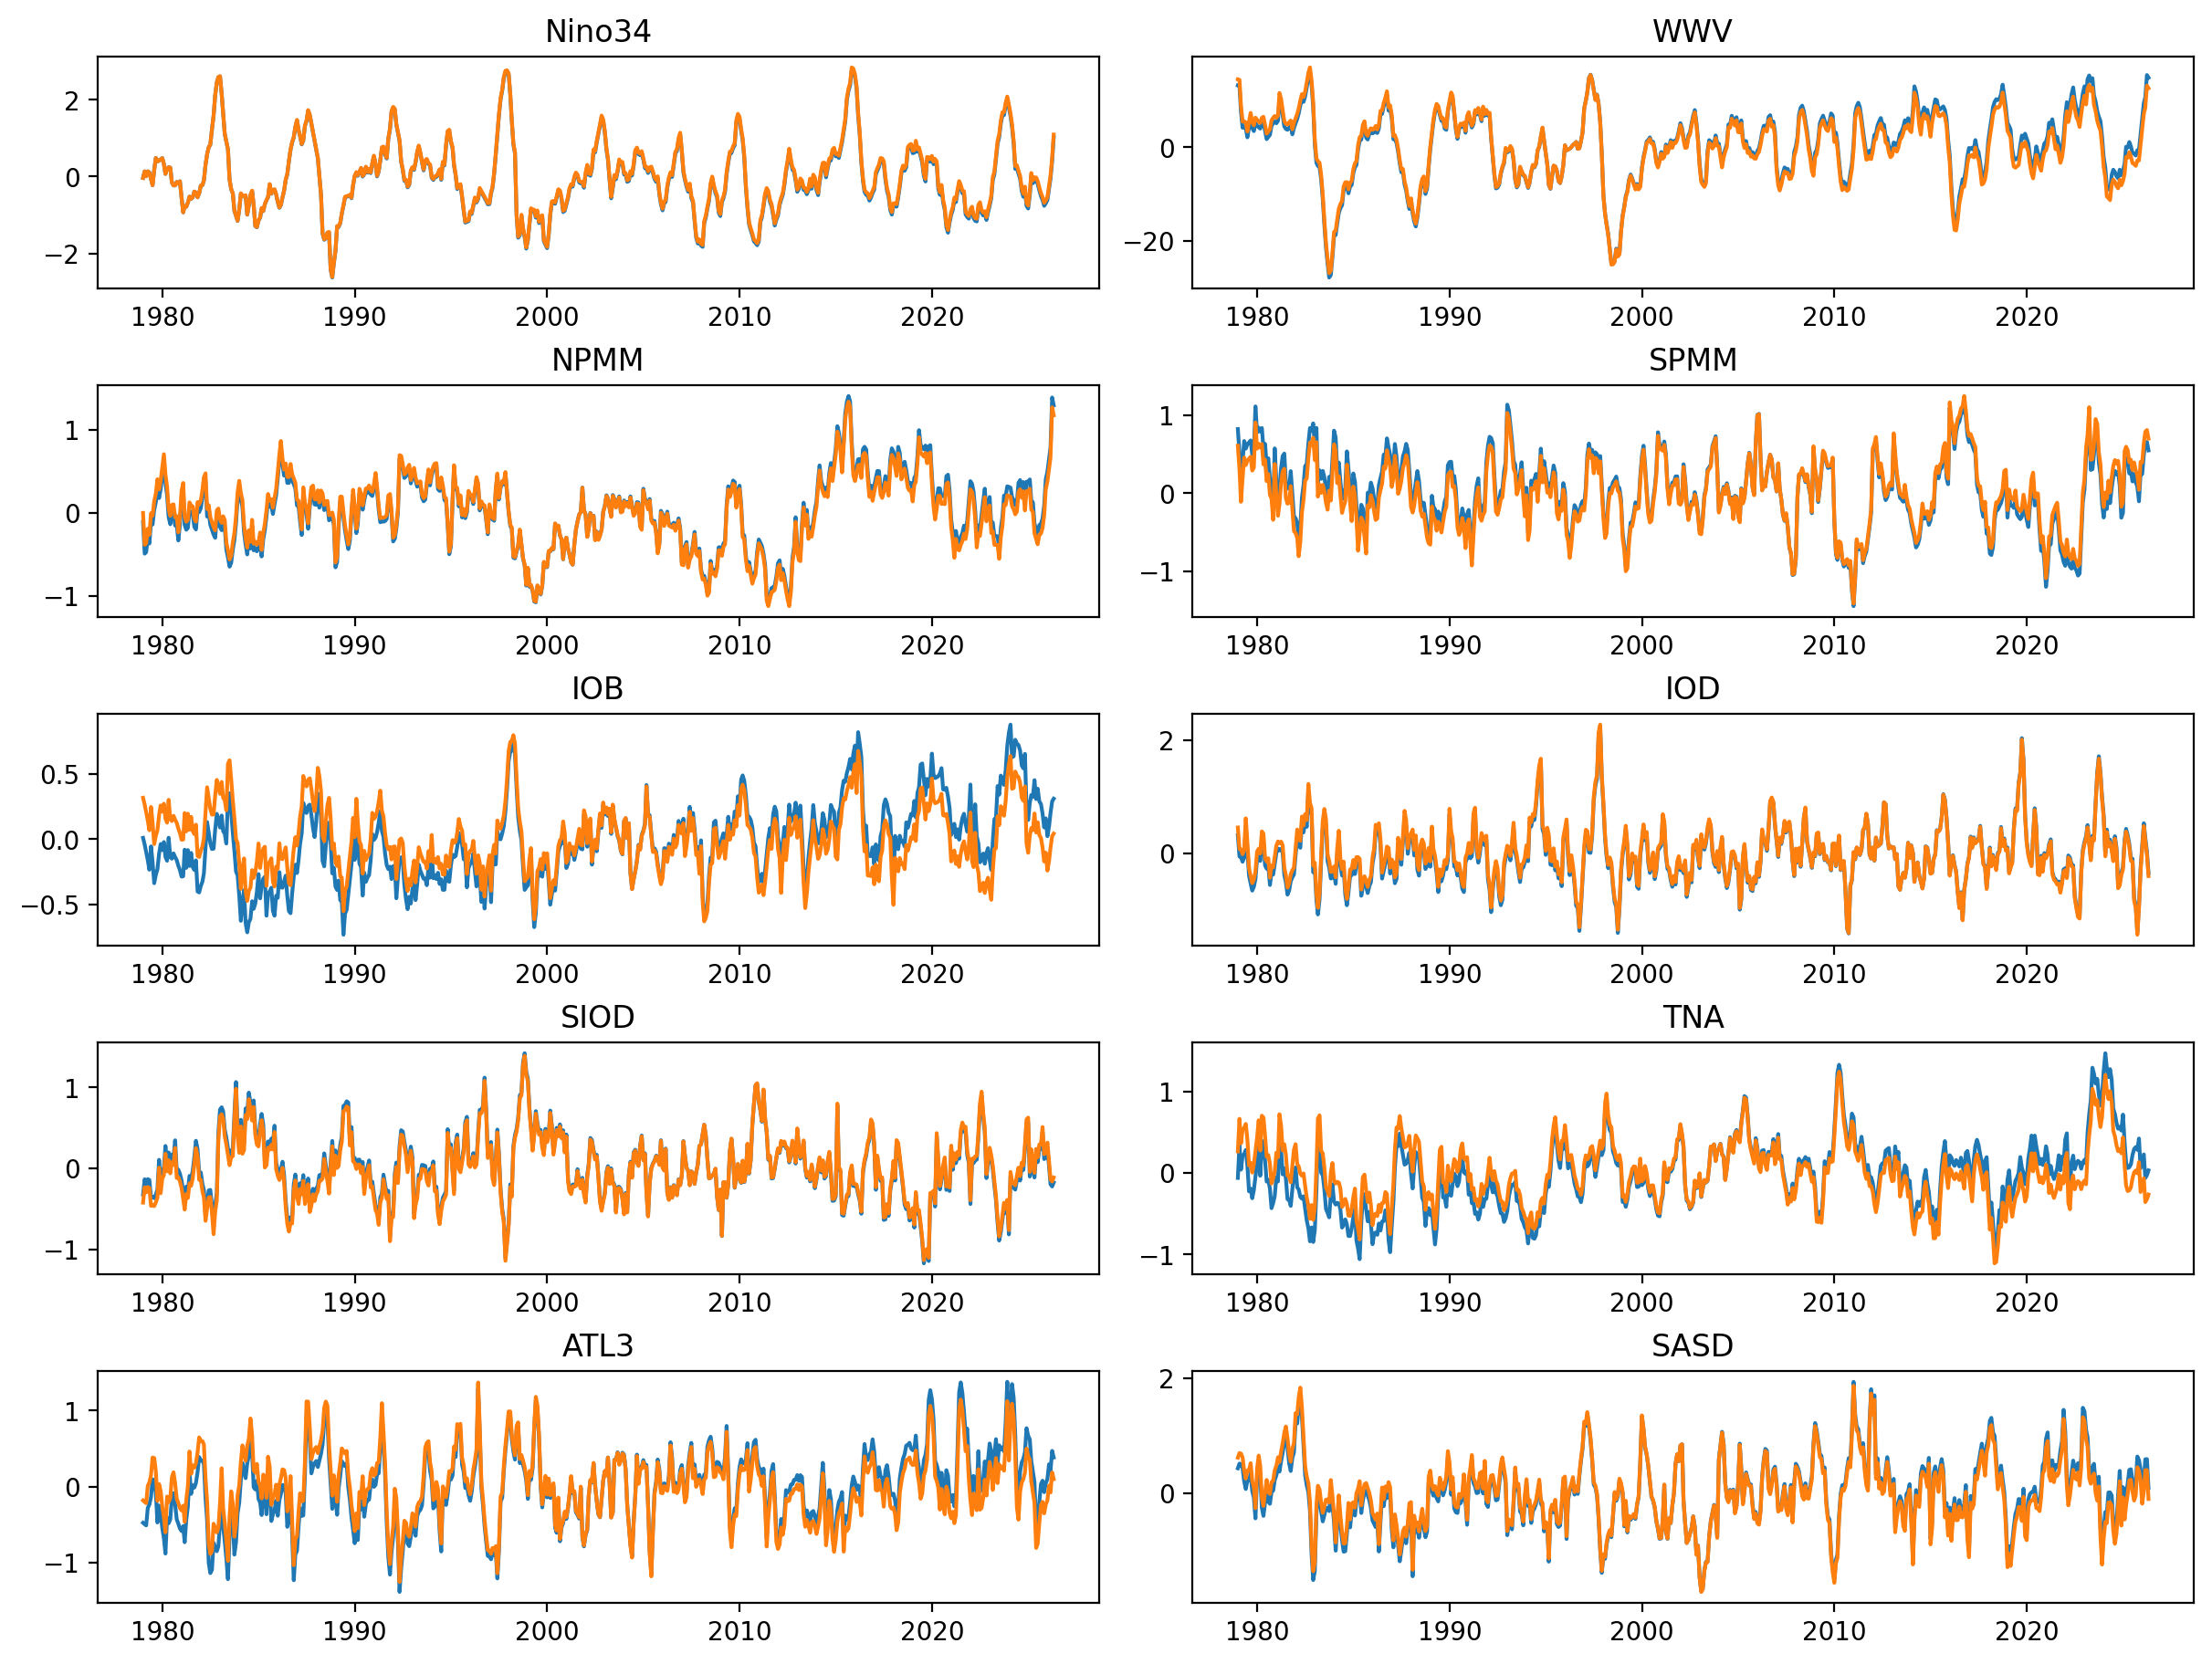

In [6]:
fig, axes = plt.subplots(5, 2, figsize=(12, 9), layout='compressed')

for i, var in enumerate(XRO_a.data_vars):
    ax = axes.flat[i]
    ax.plot(XRO_a.time, XRO_a[var], label='anom')
    ax.plot(XRO_a.time, XRO_da[var], label='detrended')
    ax.set_title(var)
